<a href="https://colab.research.google.com/github/leejunho12316/HonGongMachine/blob/main/Unstructured_%EC%82%AC%EC%9A%A9%ED%95%9C_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
%%capture --no-stderr
!sudo apt install tesseract-ocr
!sudo apt install libtesseract-dev
!sudo apt-get install poppler-utils

In [5]:
%%capture --no-stderr
!pip install -U "unstructured[all-docs]" pillow==9.5.0 pdf2image==1.16.3 layoutparser[layoutmodels,tesseract]==0.3.4

In [6]:
import nltk

nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [1]:
!pip install langchain_community langchain_openai chromadb

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 13.8 MB

In [2]:
!wget https://raw.githubusercontent.com/aws-samples/aws-ai-ml-workshop-kr/9782bcc083e72693cc1b26aa81b2201bb3d3b07c/genai/aws-gen-ai-kr/20_applications/02_qa_chatbot/01_preprocess_docs/data/complex_pdf/school_edu_guide.pdf

--2026-03-05 00:49:11--  https://raw.githubusercontent.com/aws-samples/aws-ai-ml-workshop-kr/9782bcc083e72693cc1b26aa81b2201bb3d3b07c/genai/aws-gen-ai-kr/20_applications/02_qa_chatbot/01_preprocess_docs/data/complex_pdf/school_edu_guide.pdf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2288532 (2.2M) [application/octet-stream]
Saving to: ‘school_edu_guide.pdf’

school_edu_guide.pd 100%[===================>]   2.18M  --.-KB/s    in 0.04s   

2026-03-05 00:49:11 (57.3 MB/s) - ‘school_edu_guide.pdf’ saved [2288532/2288532]



#Unstructured 사용

In [31]:
from glob import glob

In [4]:
from unstructured.partition.pdf import partition_pdf
import os

#파일위치, 저장 위치 초기화
file_path = '/content/school_edu_guide.pdf'

image_path = './fig'
os.mkdir(image_path)

In [5]:
# PDF에서 요소 추출
elements = partition_pdf(
    # 필수 파라미터
    filename=file_path,
    strategy="hi_res",
    extract_images_in_pdf=True,

    # 이미지 추출 관련
    extract_image_block_output_dir=image_path,
    extract_image_block_to_payload=False,  # False: 이미지 저장
    hi_res_model_name="yolox",

    # 청킹 관련
    chunking_strategy="by_title",
    max_characters=4096,
    new_after_n_chars=4000,
    combine_text_under_n_chars=2000,

    # 기타 파라미터
    languages=["kor", "eng"],
    pdf_infer_table_structure=True,  # 테이블 구조 추론 (deprecated 되었지만 사용)
)

yolox_l0.05.onnx:   0%|          | 0.00/217M [00:00<?, ?B/s]

In [32]:
tables, texts = [], []

images = glob(os.path.join(image_path, "*"))

for element in elements:
  if 'CompositeElement' in str(type(element)):
    for orig_element in element.metadata.orig_elements:
      if 'Table' in str(type(orig_element)):
        tables.append(orig_element)
      texts.append(element)

In [11]:
for i in range(0,10):
  print(f'비교 : {i}')
  print('TABLES')
  print(tables[i])
  print('-' * 100)

  print('TEXTS')
  print(texts[i])
  print('-' * 100)

  print(f'비교 끝')
  print("\n\n")

비교 : 0
TABLES
교육 목표 바른 인성으로 존중과 나눔을 실천하는 자주적인 어린이 몸과 마음이 건강하고 예술을 향유하는 문화적인 어린이 특기와 소질을 가꾸어 미래를 준비하는 창의적인 어린이
----------------------------------------------------------------------------------------------------
TEXTS
2024학년도

학교교육과정 설명회 연수자료 일시: 2024년 3월 20일 (수)

바른 인성, 건강한 감성, 즐거운 배움으로 미래를 가꾸는

바른 인성, 건강한 감성, 즐거운 배움으로 미래를 가꾸는

학부모 연수 순서

학부모 연수 순서

1. 상록 교육목표 및 구현계획 2. 2024학년도 학사 일정 안내 3. 출결 관련 확인 제출자료 안내 4. 학교교육평가 5. 선행교육 예방(공교육정상화법) 6. 학생 안전 교육 7. 성폭력 예방 교육 8. 흡연 및 음주 예방 교육 9. 학생 인권조례 및 교권보호 10. 방과후학교 운영 11. 초등돌봄교실(오후돌봄) 운영 12. 학부모 서비스 신청 안내 13. 정보통신윤리교육 14. 정보보안 및 개인정보보호 운영 계획 15. 불법찬조금 근절 16. 아동학대 예방 교육 17. 가정폭력 예방 교육 18. 생명 존중 및 생명 살림(자살 예방) 교육

19. 교육활동 참여자 안전교육(녹색, 학부모폴리스)

20. 학교폭력 예방 교육

21. 감염병 예방 교육

22. 청탁금지법

23. 공익제보자 보호 및 공익 신고 보상 안내 24. 존중과 배려의 교육환경 조성 예방 교육(갑질 근절) 25. 교육활동보호예방교육

1 상록 교육 목표 및 구현 계획

비전

바른 인성, 건강한 감성, 즐거운 배움으로 미래를 가꾸는 어린이

교육 목표 바른 인성으로 존중과 나눔을 실천하는 자주적인 어린이 몸과 마음이 건강하고 예술을 향유하는 문화적인 어린이 특기와 소질을 가꾸어 미래를 준비하는 창의적인 어린이

3y

=o a

수(秀),Head 록(綠),Health 상

#이미지 전처리
이미지 -> 텍스트

In [15]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, HumanMessagePromptTemplate, SystemMessagePromptTemplate

In [16]:
os.environ['OPENAI_API_KEY'] = None
model = ChatOpenAI(model = 'gpt-4o', temperature = 0)

프롬프트 구성

In [25]:
#system_prompt
system_prompt = "You are an assistant tasked with describing table and image."
system_message_template = SystemMessagePromptTemplate.from_template(system_prompt)
print(system_message_template)

# prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={},
#                       template='You are an assistant tasked with describing table and image.')
# additional_kwargs={}

prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an assistant tasked with describing table and image.') additional_kwargs={}


In [26]:
#Human_prompt
human_prompt = [
    {
        "type": "image_url",
        "image_url": {
            "url": "data:image/png;base64," + "{image_base64}",
        },
    },
    {
        "type": "text",
        "text": '''
                 Given image, give a concise summary.
                 Don't insert any XML tag such as <text> and </text> when answering.
                 Write in Korean.
        '''
    },
]
human_message_template = HumanMessagePromptTemplate.from_template(human_prompt)
print(human_message_template)

#prompt=[ImagePromptTemplate(input_variables=['image_base64'], input_types={}, partial_variables={},
#        template={'url': 'data:image/png;base64,{image_base64}'}),

#        PromptTemplate(input_variables=[], input_types={}, partial_variables={},
#        template="\n                 Given image, give a concise summary.\n
#        Don't insert any XML tag such as <text> and </text> when answering.\n
#        Write in Korean.\n        ")] additional_kwargs={}

prompt=[ImagePromptTemplate(input_variables=['image_base64'], input_types={}, partial_variables={}, template={'url': 'data:image/png;base64,{image_base64}'}), PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template="\n                 Given image, give a concise summary.\n                 Don't insert any XML tag such as <text> and </text> when answering.\n                 Write in Korean.\n        ")] additional_kwargs={}


In [28]:
#Final Prompt
prompt = ChatPromptTemplate.from_messages([system_message_template,human_message_template])
print(prompt)

# input_variables=['image_base64'] input_types={} partial_variables={}

# messages=[
    # SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[],
#  input_types={}, partial_variables={}, template='You are an assistant tasked with describing table and image
#  .'), additional_kwargs={}),

# HumanMessagePromptTemplate(prompt=[ImagePromptTemplate(input_variables=
#  ['image_base64'], input_types={}, partial_variables={},
#  template={'url': 'data:image/png;base64,{image_base64}'}),
#  PromptTemplate(input_variables=[], input_types={}, partial_variables={},
#                 template="\n                 Given image, give a concise summary.\n                 D
#                 on't insert any XML tag such as <text> and </text> when answering.\n
#                 Write in Korean.\n        ")], additional_kwargs={})
#  ]


input_variables=['image_base64'] input_types={} partial_variables={} messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an assistant tasked with describing table and image.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=[ImagePromptTemplate(input_variables=['image_base64'], input_types={}, partial_variables={}, template={'url': 'data:image/png;base64,{image_base64}'}), PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template="\n                 Given image, give a concise summary.\n                 Don't insert any XML tag such as <text> and </text> when answering.\n                 Write in Korean.\n        ")], additional_kwargs={})]


In [49]:
from langchain_core.output_parsers import StrOutputParser

llm_chain_summarize = prompt | model | StrOutputParser()

image base64 인코딩

In [33]:
import base64

def image_to_base64(image_path):

    with open(image_path, "rb") as image_file:
        encoded_string = base64.b64encode(image_file.read())

    return encoded_string.decode('utf-8')

img_info = [image_to_base64(img_path) for img_path in images if os.path.basename(img_path).startswith("figure")]

이미지 변환

In [54]:
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

In [50]:
image_summaries = llm_chain_summarize.batch(img_info, config = {'max_concurrency' : 10})

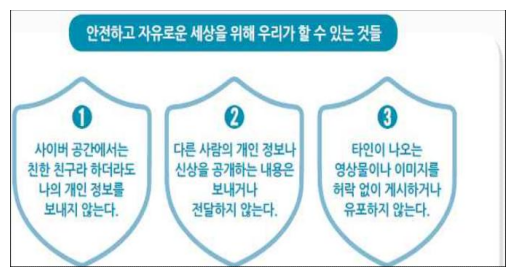

안전하고 자유로운 세상을 위해 우리가 할 수 있는 것들에 대한 내용입니다:

1. 사이버 공간에서 친한 친구라 하더라도 나의 개인 정보를 보내지 않는다.
2. 다른 사람의 개인 정보나 신상을 공개하는 내용을 보내거나 전달하지 않는다.
3. 타인이 나오는 영상물이나 이미지를 허락 없이 게시하거나 유포하지 않는다.


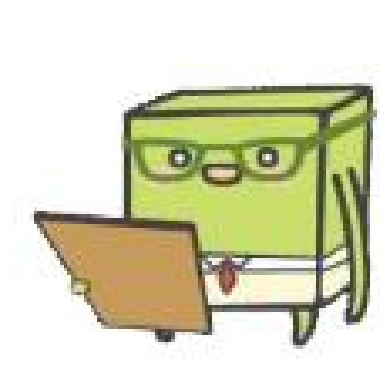

안경을 쓴 녹색 상자 모양의 캐릭터가 서류를 들고 있는 모습입니다. 캐릭터는 넥타이를 매고 있습니다.


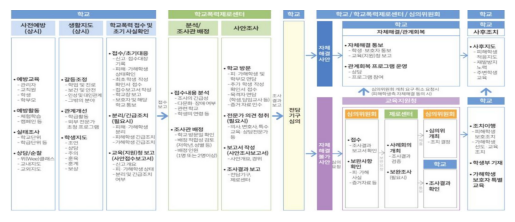

이 이미지는 학교 폭력 예방 및 대응 절차를 설명하는 흐름도입니다. 

1. **사전 예방**: 예방 교육, 예방 활동, 실태 조사, 상담 및 순찰을 통해 학교 폭력을 미리 방지합니다.

2. **생활지도**: 갈등 조정, 관계 개선, 학생 지도를 통해 학생들의 생활을 지도합니다.

3. **학교폭력 접수 및 초기 사실확인**: 신고 접수, 초기 대응, 분리 및 긴급 조치를 통해 초기 상황을 파악합니다.

4. **분석/조사관 배정**: 접수 내용 분석 후 조사관을 배정하여 사건을 조사합니다.

5. **사안 조사**: 학교 방문, 전문가 의견 청취, 보고서 작성 및 결과 보고를 통해 사건을 조사합니다.

6. **자체 해결/관계 회복**: 자체 해결 방안 및 관계 회복 프로그램을 운영합니다.

7. **심의위원회**: 심의위원회에서 조사 결과를 검토하고 조치를 결정합니다.

8. **사후 조치**: 피해 학생 지원 및 가해 학생 특별 교육을 통해 사후 관리를 진행합니다.


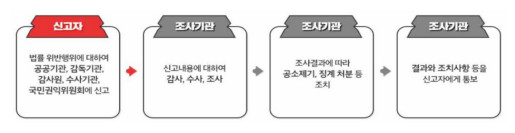

이 이미지는 신고 절차를 설명하는 흐름도입니다. 

1. **신고자**: 법률 위반 행위에 대해 공공기관, 감독기관, 감사원, 수사기관, 국민권익위원회에 신고합니다.
2. **조사기관**: 신고 내용에 대해 감사, 수사, 조사를 진행합니다.
3. **조사기관**: 조사 결과에 따라 공소 제기, 징계 처분 등의 조치를 취합니다.
4. **조사기관**: 결과와 조치 사항 등을 신고자에게 통보합니다.


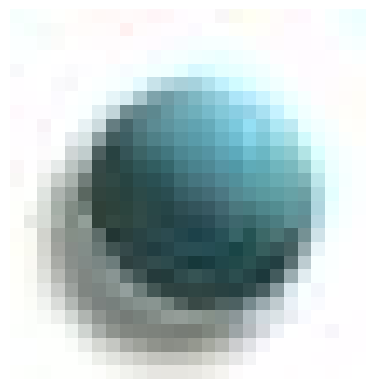

작은 구 형태의 이미지로, 청록색 계열의 색상을 띠고 있습니다. 빛을 받아 반짝이는 효과가 있습니다.


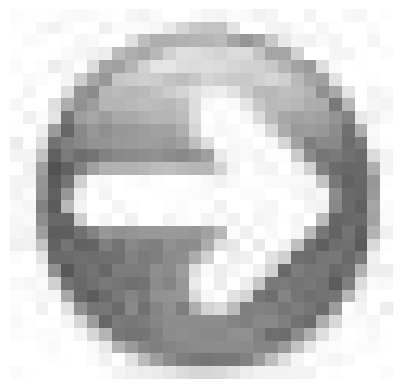

회색 원 안에 흰색 화살표가 오른쪽을 가리키고 있는 아이콘입니다.


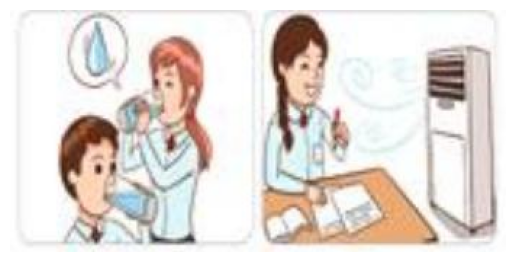

왼쪽 그림에서는 두 사람이 물을 마시고 있습니다. 오른쪽 그림에서는 한 사람이 에어컨 앞에서 공부하고 있습니다.


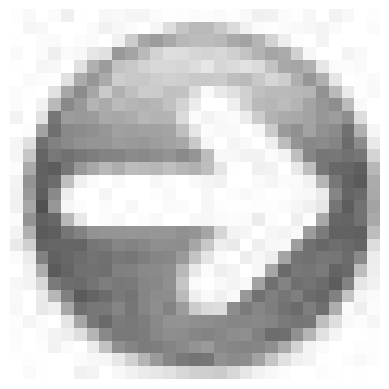

회색 원 안에 흰색 화살표가 오른쪽을 가리키고 있는 아이콘입니다.


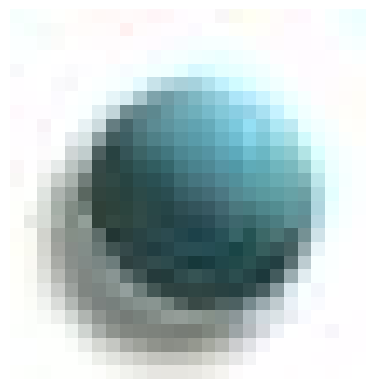

작은 구 모양의 이미지로, 청록색 계열의 색상을 띠고 있습니다. 그림자 효과가 있어 입체적으로 보입니다.


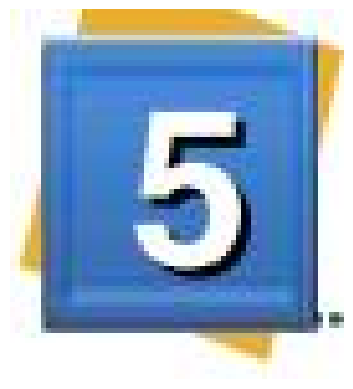

파란색 배경에 흰색 숫자 5가 있는 이미지입니다.


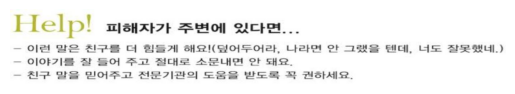

피해자가 주변에 있을 때 어떻게 도와야 하는지에 대한 조언을 제공하는 이미지입니다. 친구에게 상처 주는 말을 피하고, 이야기를 잘 들어주며, 소문내지 말고, 친구의 말을 믿고 전문가의 도움을 받도록 권장하라는 내용이 포함되어 있습니다.


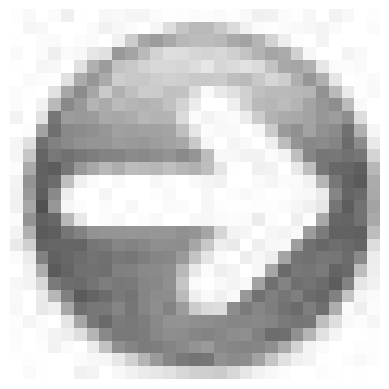

회색 원 안에 흰색 화살표가 오른쪽을 가리키고 있는 아이콘입니다.


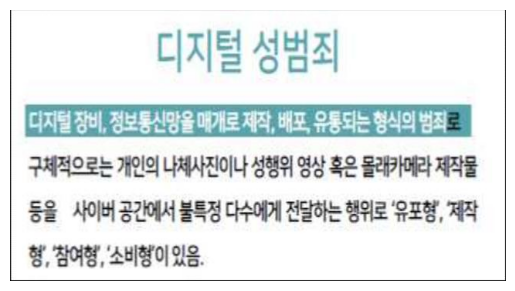

디지털 성범죄에 대한 설명입니다. 디지털 장비와 정보통신망을 이용해 제작, 배포, 유통되는 범죄로, 개인의 나체사진이나 성행위 영상 등을 불특정 다수에게 전달하는 행위를 포함합니다. 유형으로는 '유포형', '제작형', '참여형', '소비형'이 있습니다.


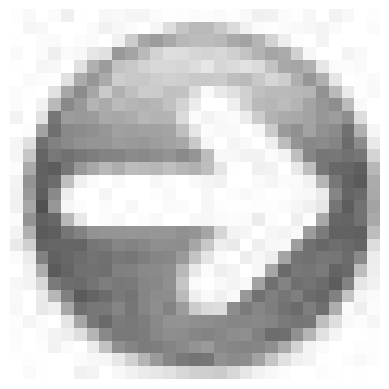

회색 원 안에 흰색 화살표가 오른쪽을 가리키고 있는 아이콘입니다.


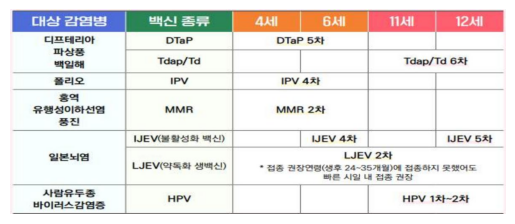

이 이미지는 연령별 예방접종 일정표입니다. 

- **디프테리아, 파상풍, 백일해**: 
  - 4세: DTaP 5차
  - 12세: Tdap/Td 6차

- **폴리오**: 
  - 4세: IPV 4차

- **홍역, 유행성이하선염, 풍진**: 
  - 4세: MMR 2차

- **일본뇌염**: 
  - 6세: IJEV 4차
  - 12세: IJEV 5차, LJEV 2차 (권장 연령에 접종하지 못했을 경우 빠른 시일 내 접종 권장)

- **사람유두종바이러스감염증**: 
  - 12세: HPV 1차~2차

각 연령대에 맞춰 필요한 백신 접종을 안내하고 있습니다.


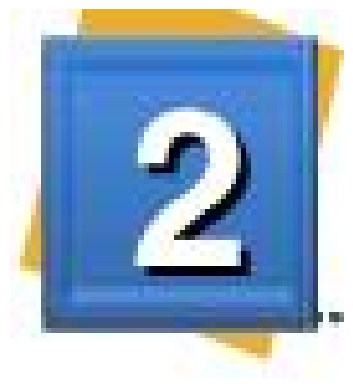

파란색 사각형 안에 흰색 숫자 2가 있습니다. 배경에 노란색 도형이 겹쳐져 있습니다.


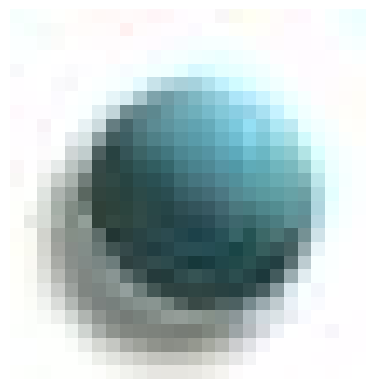

작은 구 모양의 이미지로, 청록색 계열의 색상을 띠고 있습니다. 그림자 효과가 있어 입체적으로 보입니다.


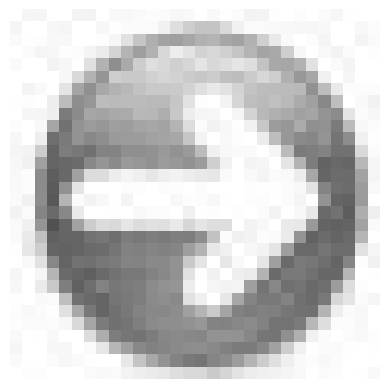

회색 원 안에 흰색 화살표가 오른쪽을 가리키고 있는 아이콘입니다.


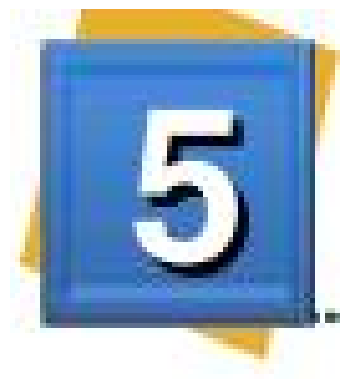

파란색 사각형 안에 숫자 5가 흰색으로 표시되어 있으며, 배경에 노란색 도형이 겹쳐져 있습니다.


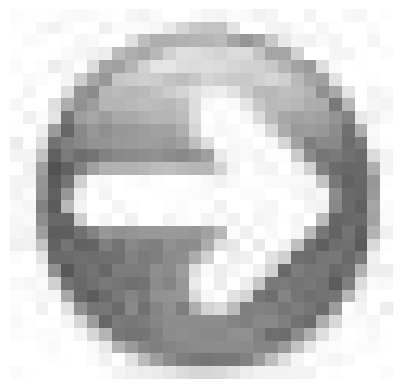

회색 원 안에 흰색 화살표가 오른쪽을 가리키고 있는 아이콘입니다.


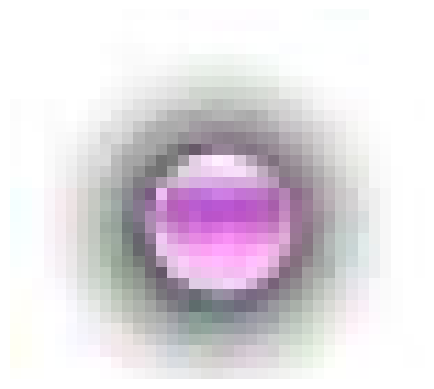

이미지는 중앙에 보라색 구슬이 있고, 주변에 흐릿한 회색과 분홍색의 원형 광채가 퍼져 있는 모습입니다.


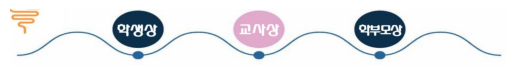

이미지는 세 개의 원형 아이콘이 물결 모양의 선 위에 배치된 모습입니다. 각 아이콘에는 "학생상", "교사상", "학부모상"이라는 글자가 적혀 있습니다. 왼쪽 아이콘과 오른쪽 아이콘은 남색 배경에 흰색 글자, 가운데 아이콘은 분홍색 배경에 흰색 글자로 되어 있습니다. 왼쪽에는 주황색 장식이 있습니다.


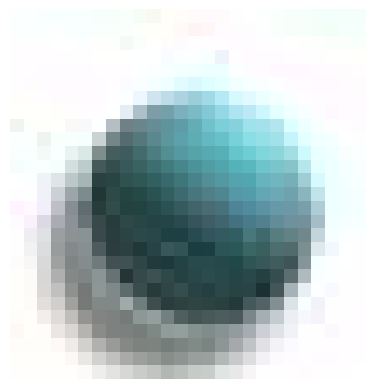

이미지는 작은 구형의 청록색 구슬을 보여줍니다.


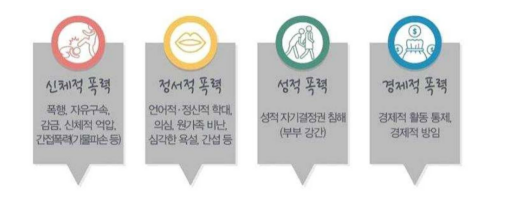

이 이미지는 네 가지 유형의 폭력을 설명하고 있습니다. 

1. **신체적 폭력**: 폭행, 자유구속, 감금, 신체적 위협, 간접폭력(물피손 등).
2. **정서적 폭력**: 언어적·정신적 학대, 의심, 원가족 비난, 심각한 욕설, 간섭 등.
3. **성적 폭력**: 성적 자기결정권 침해 (부부 강간).
4. **경제적 폭력**: 경제적 활동 통제, 경제적 방임.


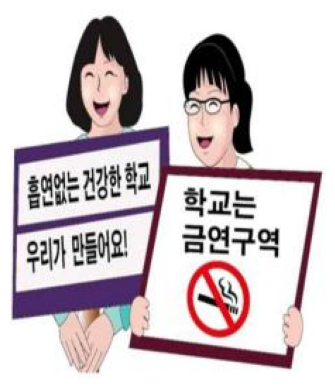

두 사람이 각각 팻말을 들고 있는 그림입니다. 왼쪽 팻말에는 "흡연없는 건강한 학교 우리가 만들어요!"라고 적혀 있고, 오른쪽 팻말에는 "학교는 금연구역"과 금연 표지가 그려져 있습니다.


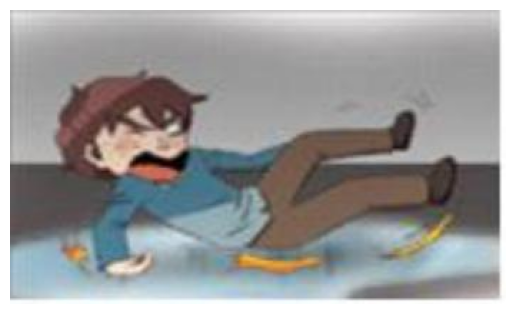

캐릭터가 바닥에 물웅덩이와 바나나 껍질 때문에 미끄러져 넘어지는 장면입니다. 놀란 표정을 짓고 있습니다.


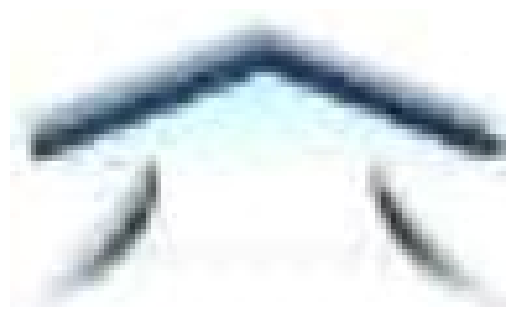

화살표 모양의 아이콘으로, 위쪽을 가리키고 있습니다.


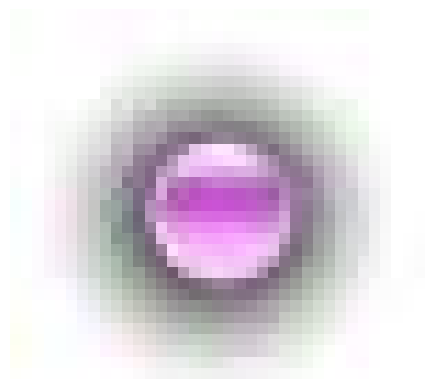

보라색 구체가 중앙에 위치하고 있으며, 주변에 흐릿한 회색 음영이 퍼져 있는 이미지입니다.


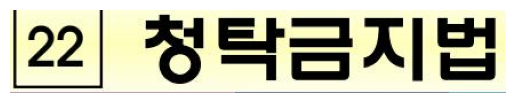

22 청탁금지법


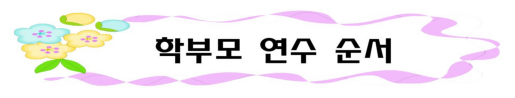

학부모 연수 순서


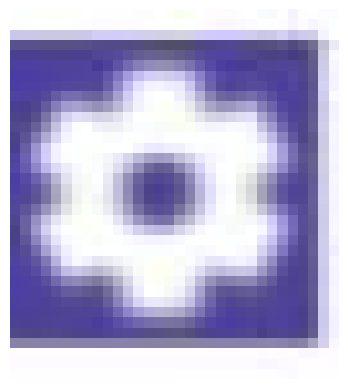

이미지는 보라색 배경에 흰색 톱니바퀴 모양이 그려져 있습니다.


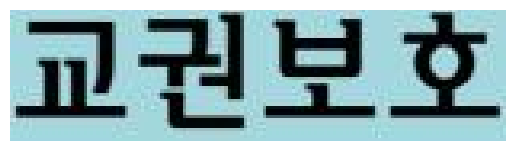

교권보호


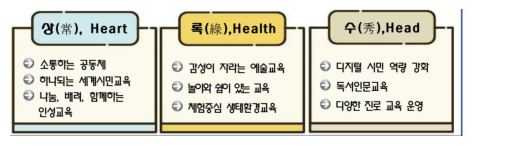

상(常), Heart: 소통하는 공동체, 하나되는 세계시민교육, 나눔, 배려, 함께하는 인성교육

록(綠), Health: 감성이 자라는 예술교육, 놀이와 삶이 있는 교육, 체험중심 생태환경교육

수(秀), Head: 디지털 시민 역량 강화, 독서인문교육, 다양한 진로 교육 운영


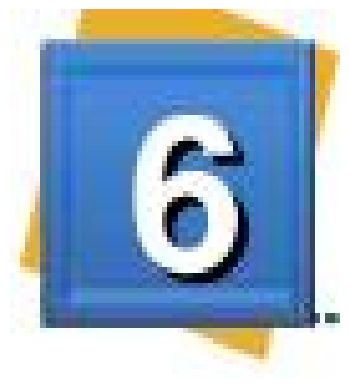

파란색 사각형 안에 흰색 숫자 6이 있습니다. 배경에 노란색 도형이 겹쳐져 있습니다.


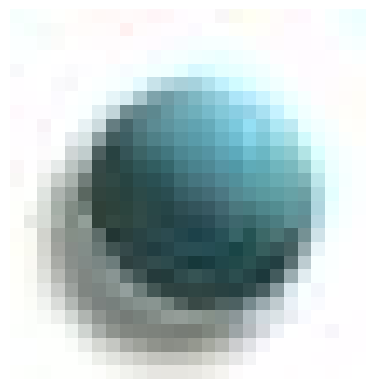

작은 구 모양의 이미지로, 청록색 계열의 색상을 띠고 있습니다. 빛이 반사되어 밝은 부분이 보입니다.


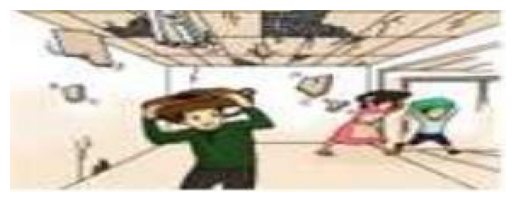

사람들이 방 안에서 머리를 보호하며 대피하는 모습입니다. 천장이 무너지고 있어 위험한 상황입니다.


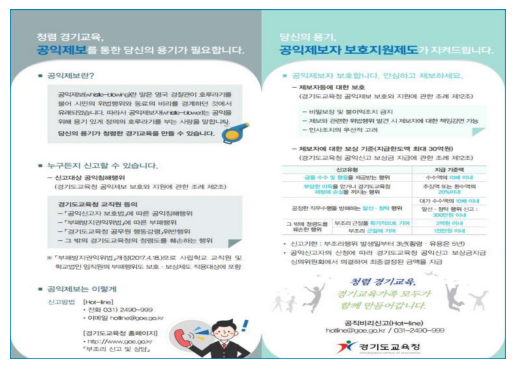

청렴 경기교육을 위한 공익제보 안내문입니다. 공익제보란 시민의 안전과 공익을 위해 부정행위를 알리는 것으로, 누구나 신고할 수 있습니다. 제보자는 보호받으며, 비밀보장과 불이익 방지, 인사조치 우선 고려 등의 보호조치가 제공됩니다. 보상 기준도 명시되어 있으며, 신고 방법은 전화나 이메일을 통해 가능합니다. 경기교육청은 청렴한 교육 환경을 만들기 위해 노력하고 있습니다.


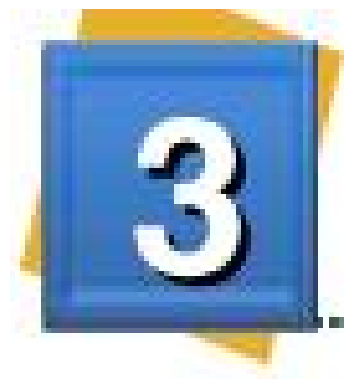

파란색 사각형 안에 흰색 숫자 3이 있습니다. 배경에 노란색 도형이 겹쳐져 있습니다.


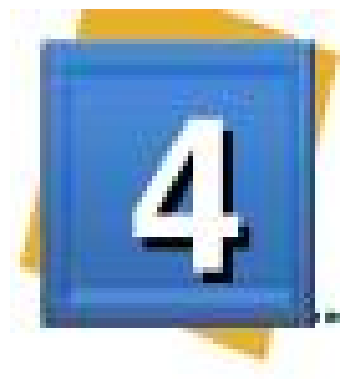

파란색 사각형 안에 흰색 숫자 4가 있습니다. 배경에는 노란색 도형이 겹쳐져 있습니다.


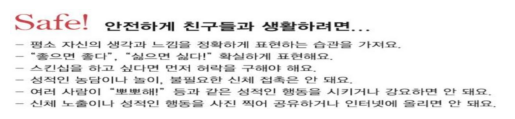

안전하게 친구들과 생활하기 위한 지침이 나와 있습니다. 자신의 생각과 느낌을 정확히 표현하고, 스킨십을 원할 때는 허락을 구해야 하며, 성적인 농담이나 불필요한 신체 접촉을 피해야 합니다. 또한, 성적인 행동을 강요하거나 신체 노출 사진을 공유해서는 안 됩니다.


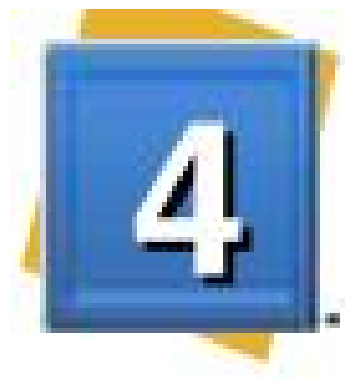

파란색 사각형 안에 숫자 4가 흰색으로 표시되어 있습니다. 배경에는 노란색 도형이 겹쳐져 있습니다.


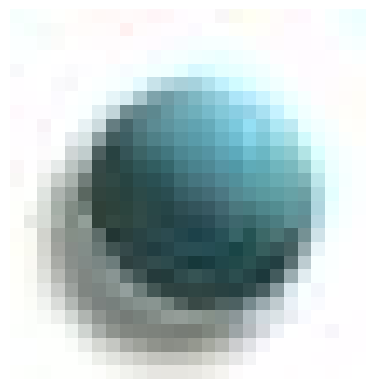

작은 구 모양의 이미지로, 청록색 계열의 색상을 띠고 있습니다. 그림자 효과가 있어 입체적으로 보입니다.


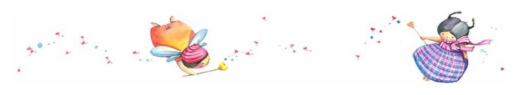

이미지에는 날개 달린 벌레와 마법 지팡이를 든 소녀가 그려져 있습니다. 둘 사이에는 작은 하트와 점들이 흩어져 있습니다. 그림은 동화적인 분위기를 자아냅니다.


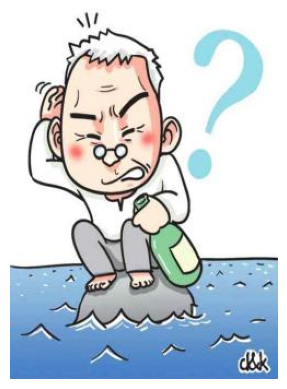

만화 스타일의 이미지입니다. 한 남자가 작은 바위 위에 앉아 있으며, 바다에 둘러싸여 있습니다. 그는 한 손에 병을 들고 있고, 다른 손으로 머리를 긁적이며 당황한 표정을 짓고 있습니다. 그의 옆에는 큰 물음표가 그려져 있습니다.


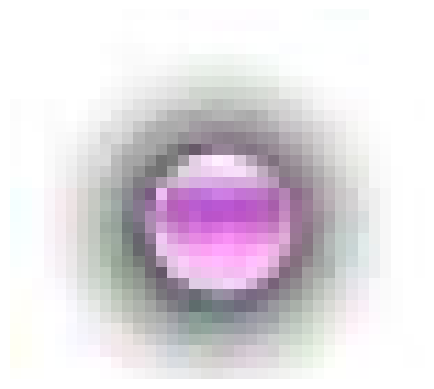

보라색 구슬이 중앙에 있고, 주변에 흐릿한 회색과 흰색의 원형이 있습니다.


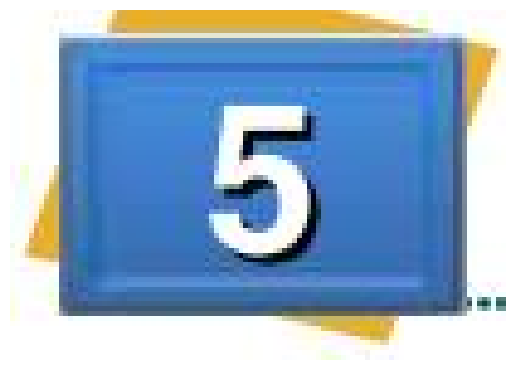

이미지는 파란색 사각형 안에 흰색 숫자 5가 있는 그림입니다. 배경에는 노란색 도형이 있습니다.


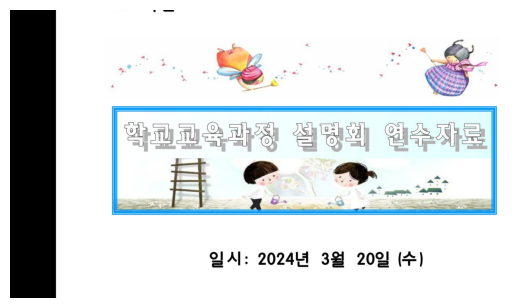

학교 교육과정 설명회 연수자료에 대한 이미지입니다. 상단에는 두 명의 캐릭터가 하늘을 날고 있으며, 중앙에는 "학교 교육과정 설명회 연수자료"라는 문구가 있습니다. 하단에는 두 명의 아이가 물을 주고 있는 그림이 있으며, 날짜는 2024년 3월 20일(수)로 표시되어 있습니다.


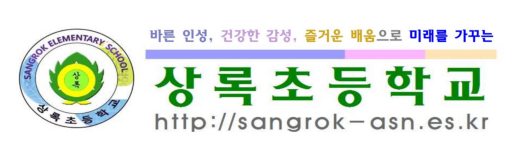

상록초등학교의 로고와 웹사이트 주소가 포함된 이미지입니다. 상단에는 "바른 인성, 건강한 감성, 즐거운 배움으로 미래를 가꾸는"이라는 문구가 적혀 있습니다. 웹사이트 주소는 "http://sangrok-asn.es.kr"입니다.


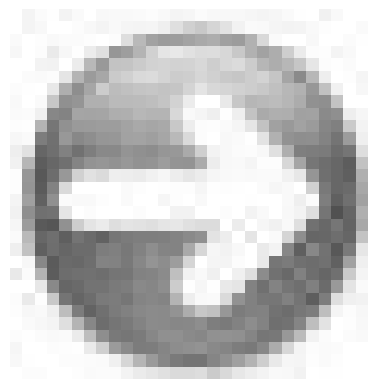

회색 원 안에 흰색 화살표가 오른쪽을 가리키고 있는 이미지입니다.


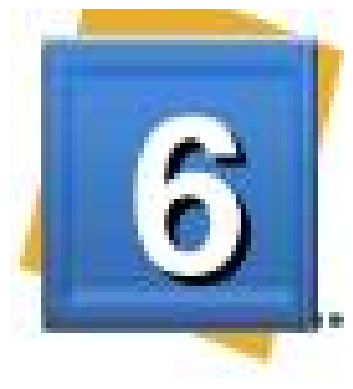

파란색 배경에 흰색 숫자 6이 있는 이미지입니다. 배경은 약간 기울어진 노란색 사각형 위에 있습니다.


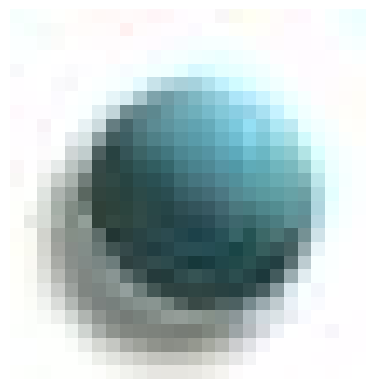

작은 구 형태의 이미지로, 청록색 계열의 색상을 띠고 있습니다. 빛을 받아 반사되는 부분이 있으며, 3D 효과가 느껴집니다.


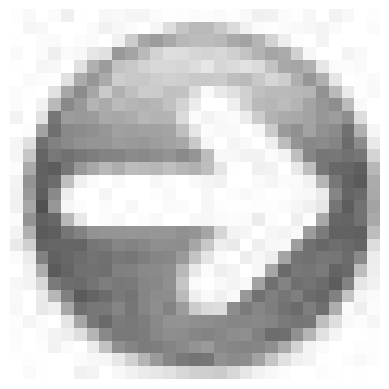

회색 원 안에 흰색 화살표가 오른쪽을 가리키고 있는 아이콘입니다.


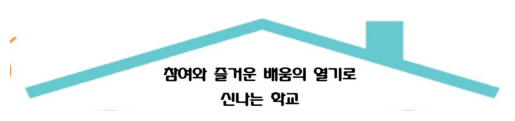

참여와 즐거운 배움의 열기로 신나는 학교


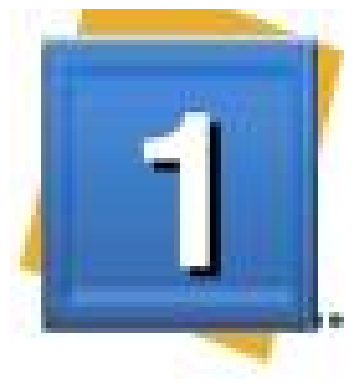

파란색 사각형 안에 흰색 숫자 1이 있는 이미지입니다. 배경에 노란색 도형이 겹쳐져 있습니다.


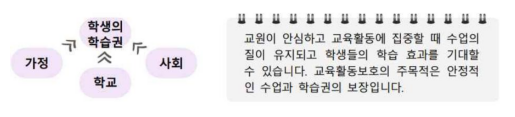

학생의 학습권은 가정, 학교, 사회의 지원을 통해 보장됩니다. 교원이 교육활동에 집중할 수 있을 때 수업의 질이 유지되고, 학생들의 학습 효과를 기대할 수 있습니다. 교육활동보호는 안정적인 수업과 학습권의 보장입니다.


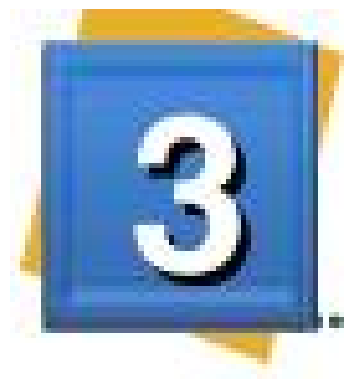

파란색 사각형 안에 흰색 숫자 3이 있습니다. 배경에 약간의 노란색이 보입니다.


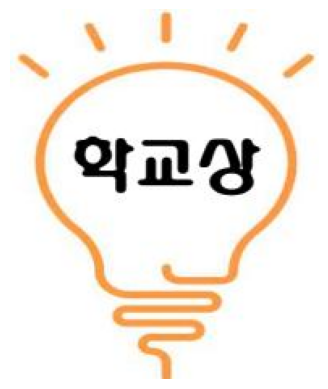

전구 모양 안에 "학교상"이라는 글자가 쓰여 있습니다. 전구 주위에는 빛을 나타내는 선들이 그려져 있습니다.


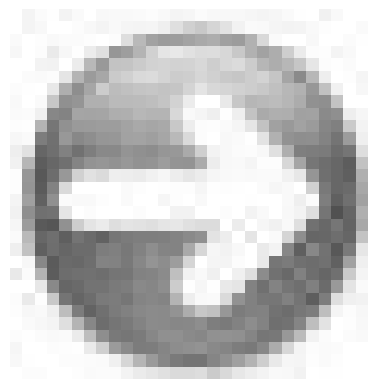

회색 원 안에 흰색 화살표가 오른쪽을 가리키고 있는 아이콘입니다.


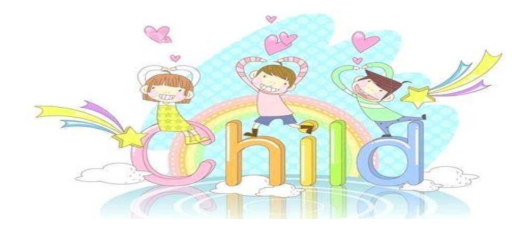

이미지에는 "Child"라는 단어가 알록달록하게 쓰여 있고, 그 위에 세 명의 아이들이 즐겁게 뛰어놀고 있습니다. 배경에는 무지개와 하트, 별이 그려져 있어 밝고 행복한 분위기를 연출하고 있습니다.


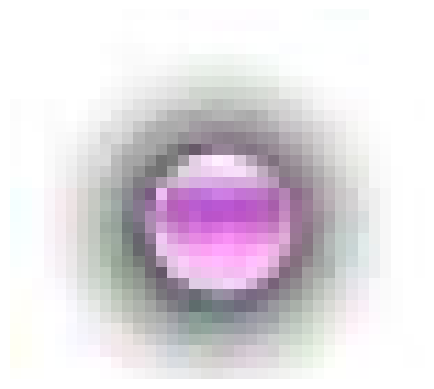

보라색 구슬이 중앙에 있고, 주변에 흐릿한 회색과 분홍색의 원형 광채가 퍼져 있습니다.


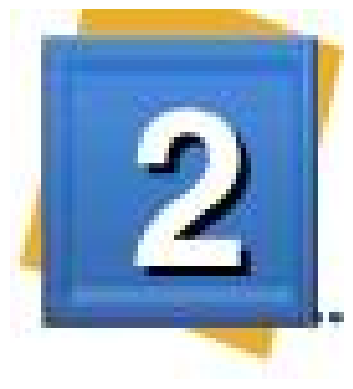

파란색 사각형 안에 숫자 2가 흰색으로 표시되어 있습니다. 배경에 노란색 도형이 겹쳐져 있습니다.


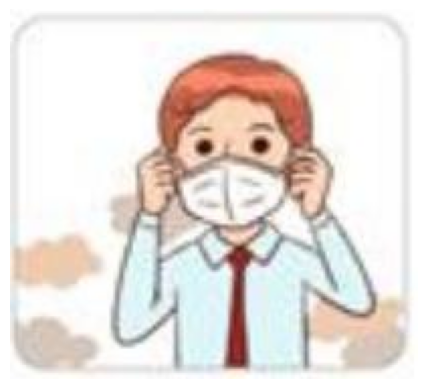

한 남성이 마스크를 착용하고 있는 일러스트입니다. 그는 셔츠와 넥타이를 착용하고 있으며, 배경에는 구름이 있습니다.


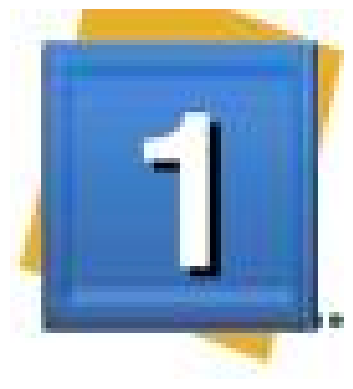

파란색 사각형 안에 흰색 숫자 1이 있습니다. 배경에 노란색 도형이 겹쳐져 있습니다.


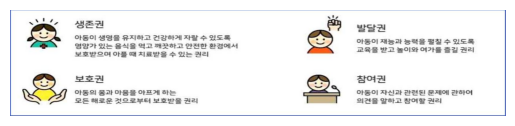

이 이미지는 아동의 권리에 대해 설명하고 있습니다. 

1. 생존권: 아동이 건강하게 자랄 수 있도록 영양가 있는 음식을 먹고 안전한 환경에서 보호받으며 치료받을 권리.
2. 발달권: 아동이 재능과 능력을 펼칠 수 있도록 교육을 받고 여가를 즐길 권리.
3. 보호권: 아동의 몸과 마음을 해롭게 하는 모든 것으로부터 보호받을 권리.
4. 참여권: 아동이 자신과 관련된 문제에 대해 의견을 말하고 참여할 권리.


In [55]:
for i in range(len(img_info)):
  plt.imshow(Image.open(BytesIO(base64.b64decode(img_info[i]))))
  plt.axis('off')
  plt.show()
  print(image_summaries[i])

#테이블 전처리

In [56]:
human_prompt = [
    {
        "type": "text",
        "text": '''
                 Here is the table: <table>{table}</table>
                 Given table, give a markdown table
                 Don't insert any XML tag such as <table> and </table> when answering.
                 Write in Korean.
        '''
    },
]
human_message_template = HumanMessagePromptTemplate.from_template(human_prompt)

In [57]:
prompt = ChatPromptTemplate.from_messages(
    [
        system_message_template,
        human_message_template
    ]
)

In [59]:
llm_chain_summarize = {'table' : lambda x : x} | prompt | model | StrOutputParser()

In [71]:
table_summaries = llm_chain_summarize.batch(tables, config = {'max_concurrency' : 10})

In [75]:
for i in range(len(table_summaries)):
  print(tables[i])
  print("\n")
  print(table_summaries[i])
  print("\n")
  print('*' * 100)
  print("\n")

교육 목표 바른 인성으로 존중과 나눔을 실천하는 자주적인 어린이 몸과 마음이 건강하고 예술을 향유하는 문화적인 어린이 특기와 소질을 가꾸어 미래를 준비하는 창의적인 어린이


| 교육 목표 | 바른 인성으로 존중과 나눔을 실천하는 자주적인 어린이 | 몸과 마음이 건강하고 예술을 향유하는 문화적인 어린이 | 특기와 소질을 가꾸어 미래를 준비하는 창의적인 어린이 |
|-----------|--------------------------------------------------|--------------------------------------------------|--------------------------------------------------|


****************************************************************************************************


구현중점 교육활동 시기 대상 관련부서 111. 학교 교육 환경개선 ◦교실 학습 환경 구성 ◦학년 및 학급 규칙 제정 및 준수 3월,9월 3월 4~6학년 1~6학년 생활인권 ◦인권 친화적 학생 생활인권규정 제정 준수 연중 1~6학년 112. 학교교육 참여기회 확대 11. 소통하는 공동체 ◦학교 운영위원회 활성화 ◦학교 교육 설명회 ◦학부모 학교교육 참여기회 확대 연중10회 2회 연중 학운위 학부모 학부모 생활인권 생활인권 생활인권 ◦수업 공개의 날 운영 5월 학부모 교육과정 113. 전문적 학습공동체 조직 운영 ◦학년별 협의회 구성 ◦자율과정과 연계되는 학습공동체 운영 연중 전교사 교육과정 ◦자율적인 참여로 집단지성 발휘 121. 학생 자치 활동 능력 신장 ◦전교 어린이회 임원 선출 ◦전교 어린이회 운영 7월,12월 연중 3~6학년 1~6학년 생활인권 12. ◦학급임원선출 3월,8월 2~6학년 하나되는 세계시민 122. 인권교육 및 평화 교육 교육 ◦평화교육(민주시민교육) 연중 ◦인권교육주간 운영 연중 1~6학년 생활인권 ◦장

#평문 데이터 전처리

In [ ]:
human_prompt = [
    {
        "type": "text",
        "text": '''
Here is the Raw_text: <raw_text>{text}</raw_text>
IMPORTANT: 주어진 텍스트를 정보손실 없이 깔끔한 평문 형태로 작성하십시오.
중요한 점은 정보 손실은 없어야 한다는 점입니다.
        '''
    },
]
human_message_template = HumanMessagePromptTemplate.from_template(human_prompt)

In [ ]:
prompt = ChatPromptTemplate.from_messages(
    [
        system_message_template,
        human_message_template
    ]
)

#summarize_chain = prompt | llm_text | StrOutputParser()
summarize_chain = {"text": lambda x:x} | prompt | model | StrOutputParser()

In [ ]:
raw_texts = [text.text for text in texts]

In [ ]:
plain_texts = summarize_chain.batch(raw_texts, config={"max_concurrency": 5})

#VectorDB

In [84]:
from langchain_classic.retrievers.multi_vector import MultiVectorRetriever
from langchain_core.stores import InMemoryStore
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma

# 분할한 텍스트들을 색인할 벡터 저장소
vectorstore = Chroma(collection_name="multi_modal_rag",
                     embedding_function=OpenAIEmbeddings())

# 원본문서 저장을 위한 저장소 선언
docstore = InMemoryStore()
id_key = "doc_id"

# 검색기
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=docstore,
    id_key=id_key,
)

/tmp/ipykernel_3452/2514387742.py:7: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectorstore = Chroma(collection_name="multi_modal_rag",


In [1]:
import uuid

# 마크다운으로 정제한 테이블 저장
table_ids = [str(uuid.uuid4()) for _ in table_summaries]
retriever.docstore.mset(list(zip(table_ids, table_summaries)))

# 원본 이미지(base64) 데이터 저장
# img_base64_list -> GPT-4의 설명이 붙지않은 쌩 이미지
img_ids = [str(uuid.uuid4()) for _ in img_info]
retriever.docstore.mset(list(zip(img_ids, img_info)))



NameError: name 'table_summaries' is not defined

In [105]:
answer = retriever.docstore.mget([img_ids[0]])

answer
#plt.imshow(Image.open(BytesIO(base64.b64decode(img_info[i]))))

['...']

In [2]:
!pip install langchain_community langchain_openai chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.

In [50]:
import os
os.environ['OPENAI_API_KEY'] = None

In [51]:
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.stores import InMemoryStore
from langchain_classic.retrievers.multi_vector import MultiVectorRetriever

id_key = 'doc_id'

vectorstore = Chroma(embedding_function = OpenAIEmbeddings())
docstore = InMemoryStore()
retriever = MultiVectorRetriever(vectorstore = vectorstore, docstore = docstore, idkey = id_key)

In [52]:
original_texts = [
    "얼음 메이커 고장 시 조치: 먼저 급수 밸브가 열려있는지 확인하십시오. 그 다음 디스플레이에서 'Ice Maker' 버튼을 3초간 눌러 초기화합니다. 그래도 안되면 필터를 교체해야 할 수 있습니다."
]
summary_texts = [
    "얼음이 안 나올 때, 얼음 메이커 고장 해결 및 초기화 방법"
]
# [테이블 데이터]
original_tables = [
    "| 구역 | 적정 온도 | 보관 권장 식품 |\n|---|---|---|\n| 냉장실 | 2°C ~ 3°C | 반찬, 음료 |\n| 냉동실 | -18°C ~ -20°C | 육류, 아이스크림 |"
]
summary_tables = [
    "스마트 냉장고의 냉장실 및 냉동실 적정 온도와 보관 권장 식품에 대한 정보 표"
]

# [이미지 데이터]
original_images = [
    "data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAkGBxISE... (가상의 Base64 이미지 데이터)"
]
summary_images = [
    "냉장고 디스플레이에 '에러 E-04 (필터 교체 알림)'가 떠 있는 화면 사진"
]

In [53]:
#docstore에 원본 데이터 저장
import uuid
text_ids = [str(uuid.uuid4()) for _ in range(len(original_texts))]
retriever.docstore.mset(list(zip(text_ids, original_texts)))

table_ids = [str(uuid.uuid4()) for _ in range(len(original_tables))]
retriever.docstore.mset(list(zip(table_ids, original_tables)))

image_ids = [str(uuid.uuid4()) for _ in range(len(original_images))]
retriever.docstore.mset(list(zip(image_ids, original_images)))

In [54]:
#vectorstore에 요약 데이터 저장
from langchain_core.documents import Document

docs_summary_texts = [Document(page_content=summary, metadata = {id_key:  text_ids[i]})
                      for i, summary in enumerate(summary_texts)]
docs_summary_tables = [Document(page_content=summary, metadata = {id_key : table_ids[i]})
                      for i, summary in enumerate(summary_tables)]
docs_summary_images = [Document(page_content=summary, metadata = {id_key : image_ids[i]})
                      for i, summary in enumerate(summary_images)]
retriever.vectorstore.add_documents(docs_summary_texts)
retriever.vectorstore.add_documents(docs_summary_tables)
retriever.vectorstore.add_documents(docs_summary_images)

['16b63b2e-437e-4212-9836-f23974f84a50']

In [62]:
retriever.invoke('표')

['| 구역 | 적정 온도 | 보관 권장 식품 |\n|---|---|---|\n| 냉장실 | 2°C ~ 3°C | 반찬, 음료 |\n| 냉동실 | -18°C ~ -20°C | 육류, 아이스크림 |',
 'data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAkGBxISE... (가상의 Base64 이미지 데이터)']

In [ ]:
id_key의 정체

In [ ]:
import uuid

#InMemoryStore에 (랜덤 키값, 원본 text) 쌍 저장
doc_ids = [str(uuid.uuid4()) for _ in raw_texts]
retriever.docstore.mset(list(zip(doc_ids, raw_texts)))

#VectorDB에 Documents 임베딩 저장
summary_texts = [
    Document(page_content=s, metadata={id_key: doc_ids[i]})
    for i, s in enumerate(plain_texts)
]
retriever.vectorstore.add_documents(summary_texts)